In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Pandas:", pd.__version__)

Pandas: 3.0.3


In [2]:
df = pd.read_csv("../data/raw/results.csv")

In [3]:
print("Filas y columnas:")
print(df.shape)

print("\nColumnas:")
print(df.columns.tolist())


Filas y columnas:
(49477, 9)

Columnas:
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']


In [4]:
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49477 entries, 0 to 49476
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49477 non-null  str    
 1   home_team   49477 non-null  str    
 2   away_team   49477 non-null  str    
 3   home_score  49433 non-null  float64
 4   away_score  49433 non-null  float64
 5   tournament  49477 non-null  str    
 6   city        49477 non-null  str    
 7   country     49477 non-null  str    
 8   neutral     49477 non-null  bool   
dtypes: bool(1), float64(2), str(6)
memory usage: 3.1 MB


In [6]:
df.describe()

,home_score,away_score
count,49433.000000,49433.000000
mean,1.757490,1.181822
std,1.774299,1.401856
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,31.000000,21.000000


In [7]:
df.isnull().sum()

date           0
home_team      0
away_team      0
home_score    44
away_score    44
tournament     0
city           0
country        0
neutral        0
dtype: int64

In [8]:
df["date"] = pd.to_datetime(df["date"])

print("Primer partido:")
print(df["date"].min())

print("\nÚltimo partido:")
print(df["date"].max())

Primer partido:
1872-11-30 00:00:00

Último partido:
2026-06-27 00:00:00


In [9]:
teams = set(df["home_team"]).union(set(df["away_team"]))

print("Cantidad de selecciones:")
print(len(teams))

Cantidad de selecciones:
336


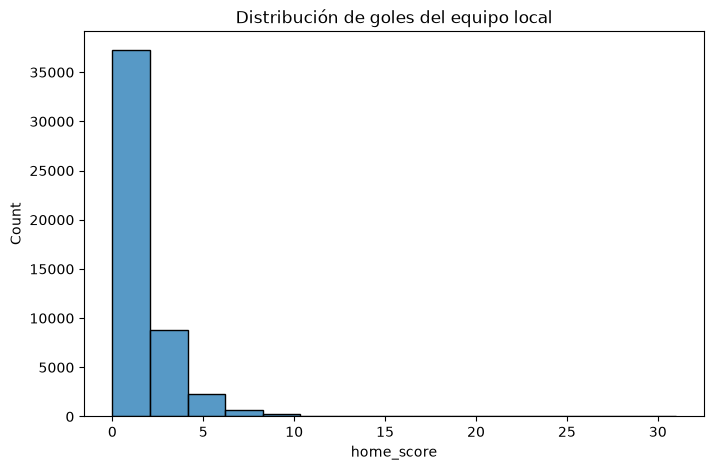

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df["home_score"], bins=15)

plt.title("Distribución de goles del equipo local")
plt.show()

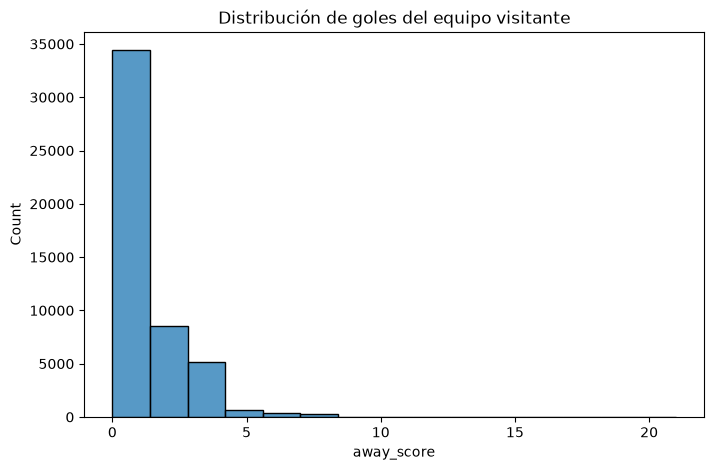

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["away_score"], bins=15)

plt.title("Distribución de goles del equipo visitante")
plt.show()

In [12]:
df["tournament"].value_counts().head(20)

tournament
Friendly                                18388
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1036
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Merdeka Tournament                        599
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Gold Cup                                  420
Gulf Cup                                  410
Island Games                              394
UEFA Euro                                 388
Asian Games                               368
Name: count, dtype: int64

In [13]:
all_teams = pd.concat([
    df["home_team"],
    df["away_team"]
])

all_teams.value_counts().head(20)

Sweden         1104
England        1093
Argentina      1072
Brazil         1062
Germany        1034
South Korea    1010
Hungary        1006
Mexico         1006
Uruguay         973
France          938
Italy           893
Poland          892
Switzerland     887
Netherlands     882
Norway          875
Denmark         874
Thailand        865
Austria         863
Belgium         856
Scotland        854
Name: count, dtype: int64

In [14]:
df[df["home_score"].isnull()]

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49433,2026-06-19,Scotland,Morocco,NaN,NaN,FIFA World Cup,Foxborough,United States,True
49434,2026-06-19,Brazil,Haiti,NaN,NaN,FIFA World Cup,Philadelphia,United States,True
49435,2026-06-19,United States,Australia,NaN,NaN,FIFA World Cup,Seattle,United States,False
49436,2026-06-19,Turkey,Paraguay,NaN,NaN,FIFA World Cup,Santa Clara,United States,True
49437,2026-06-20,Germany,Ivory Coast,NaN,NaN,FIFA World Cup,Toronto,Canada,True
49438,2026-06-20,Ecuador,Curaçao,NaN,NaN,FIFA World Cup,Kansas City,United States,True
49439,2026-06-20,Netherlands,Sweden,NaN,NaN,FIFA World Cup,Houston,United States,True
49440,2026-06-20,Tunisia,Japan,NaN,NaN,FIFA World Cup,Guadalupe,Mexico,True
49441,2026-06-21,Belgium,Iran,NaN,NaN,FIFA World Cup,Inglewood,United States,True
49442,2026-06-21,New Zealand,Egypt,NaN,NaN,FIFA World Cup,Vancouver,Canada,True


In [15]:
df[df["away_score"].isnull()]

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49433,2026-06-19,Scotland,Morocco,NaN,NaN,FIFA World Cup,Foxborough,United States,True
49434,2026-06-19,Brazil,Haiti,NaN,NaN,FIFA World Cup,Philadelphia,United States,True
49435,2026-06-19,United States,Australia,NaN,NaN,FIFA World Cup,Seattle,United States,False
49436,2026-06-19,Turkey,Paraguay,NaN,NaN,FIFA World Cup,Santa Clara,United States,True
49437,2026-06-20,Germany,Ivory Coast,NaN,NaN,FIFA World Cup,Toronto,Canada,True
49438,2026-06-20,Ecuador,Curaçao,NaN,NaN,FIFA World Cup,Kansas City,United States,True
49439,2026-06-20,Netherlands,Sweden,NaN,NaN,FIFA World Cup,Houston,United States,True
49440,2026-06-20,Tunisia,Japan,NaN,NaN,FIFA World Cup,Guadalupe,Mexico,True
49441,2026-06-21,Belgium,Iran,NaN,NaN,FIFA World Cup,Inglewood,United States,True
49442,2026-06-21,New Zealand,Egypt,NaN,NaN,FIFA World Cup,Vancouver,Canada,True


In [16]:
df.dtypes

date          datetime64[us]
home_team                str
away_team                str
home_score           float64
away_score           float64
tournament               str
city                     str
country                  str
neutral                 bool
dtype: object